# HFO Evaluation on Real-Time sEEG Data using an snn-torch-trained Network

## Check WD (change if necessary) and file loading

In [162]:
# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)

# Check if the current WD is the file location
if "/thesis-lava/src/nir" not in os.getcwd():
    # Set working directory to this file location
    file_location = f"{os.getcwd()}/thesis-lava/src/nir"
    print("File Location: ", file_location)

    # Change the current working Directory
    os.chdir(file_location)

    # New Working Directory
    print("New Working Directory: ", os.getcwd())

/home/monkin/Desktop/feup/thesis/thesis-lava/src/nir


### Add Parent Directory to Path
Need to add it to access `utils` without adding it to PATH

In [163]:
# Add grandparent directory to path (To acess sntt_utils)
import sys

current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the grandparent directory to the system path
# grandparent_dir = os.path.abspath(os.path.join(current_dir, os.pardir, os.pardir))
# sys.path.append(parent_dir)
sys.path.insert(0, parent_dir)


print(sys.path)

['/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis', '/home/monkin/Desktop/feup/ncn-lava/src', '/home/monkin/Desktop/feup/thesis/thesis-lava/src', '/home/monkin/Desktop/feup/thesis/lava-dl/src', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/monkin/Desktop/feup/thesis/.venv/lib/python3.10/site-packages', '/home/monkin/Desktop/feup/thesis/lava-dl', '/home/monkin/Desktop/feup/thesis/.venv/src/lava/src', '/home/monkin/Desktop/feup/thesis/.venv/src/lava', '/home/monkin/Desktop/feup/thesis/.venv/lib/python3.10/site-packages/setuptools/_vendor']


## Load the Network from the `NIR` file

In [164]:
from utils.hfo import band_to_file_name, MarkerType, BaselineAlgorithm

# ----- Frequency Band Parameters -----
# Declare if using ripples, fast ripples, or both
chosen_band = MarkerType.FAST_RIPPLE     # RIPPLE, FAST_RIPPLE, or BOTH
# Specify the chosen Baseline Algorithm
chosen_baseline_alg_suffix = BaselineAlgorithm.MEDIAN # BaselineAlgorithm.EIGHTY_PERC    # BaselineAlgorithm.Q3
# Get the suffix for the chosen frequency band
BAND_FILENAME = band_to_file_name(chosen_band)

In [165]:
import numpy as np
import nir
import matplotlib.pyplot as plt

# Load the Trained Network from the NIR File
NIR_FILENAME = f"{BAND_FILENAME}_{chosen_baseline_alg_suffix}_trained_net.nir"

nir_network = nir.read(f"models/{NIR_FILENAME}")

### Analyze individual Layers of the imported Network

In [166]:
nirLIF1 = nir_network.nodes["lif1"]
nirLIF2 = nir_network.nodes["lif2"]
nirLIFOut = nir_network.nodes["lif_out"]
print(nirLIF1)

CubaLIF(tau_syn=array([0.00027337, 0.00020684, 0.00029694, 0.0001266 , 0.00028942,
       0.00017805, 0.00018086, 0.00020547, 0.00024664, 0.00011793,
       0.00029177, 0.00020036, 0.00029843, 0.00025447, 0.00028037,
       0.0001865 , 0.00017841, 0.0019396 , 0.00040969, 0.00037363,
       0.00015701, 0.00015839, 0.00016286, 0.00012814], dtype=float32), tau_mem=array([0.00011864, 0.00023361, 0.00015698, 0.00017259, 0.00034534,
       0.00014197, 0.00015067, 0.00051802, 0.00033085, 0.00021419,
       0.00019028, 0.00016002, 0.00017566, 0.00015763, 0.00017741,
       0.00020649, 0.00012887, 0.00017213, 0.00013625, 0.00027133,
       0.00017605, 0.00081964, 0.00023196, 0.00011435], dtype=float32), r=array([1.1863538, 2.3360846, 1.5698305, 1.7258911, 3.4533699, 1.4196671,
       1.5067121, 5.1802025, 3.3085303, 2.1418586, 1.9027638, 1.6001774,
       1.7566377, 1.5762817, 1.7740619, 2.0649114, 1.2887096, 1.7213036,
       1.3625021, 2.7133477, 1.7605472, 8.196443 , 2.3196158, 1.1435146],
 

In [167]:
# Calculate the dv and du parameters from tau_mem and tau_syn
lif1_dv = np.array(list(map(lambda x: 1 - (1e-4 / x), nirLIF1.tau_mem)))
lif1_du = np.array(list(map(lambda x: 1 - (1e-4 / x), nirLIF1.tau_syn)))

lif2_dv = np.array(list(map(lambda x: 1 - (1e-4 / x), nirLIF2.tau_mem)))
lif2_du = np.array(list(map(lambda x: 1 - (1e-4 / x), nirLIF2.tau_syn)))

lif_out_dv = 1 - (1e-4 / nirLIFOut.tau_mem)
lif_out_du = 1 - (1e-4 / nirLIFOut.tau_syn)

In [168]:
nirLIFOut

CubaLIF(tau_syn=np.float32(0.00025984697), tau_mem=np.float32(0.00025984686), r=np.float32(2.5984685), v_leak=np.float32(0.0), v_threshold=np.float32(1.0), w_in=np.float32(2.5984697), input_type={'input': array([], dtype=float64)}, output_type={'output': array([], dtype=float64)}, metadata={}, num_neurons=np.int64(1))

In [169]:
# Print the network summary
print(f"NIR Network Info: Nº Nodes: {len(nir_network.nodes)} | Nº Edges: {len(nir_network.edges)}")

print("Nodes: ", nir_network.nodes)
print(f"\nLIF Nodes dv and du: LIF1: dv: {lif1_dv} | du: {lif1_du}\nLIF2: dv: {lif2_dv} | du: {lif2_du}\nLIFOut: dv: {lif_out_dv} | du: {lif_out_du}")

print("\nEdges: ", nir_network.edges)

NIR Network Info: Nº Nodes: 8 | Nº Edges: 7
Nodes:  {'fc3': Linear(weight=array([[-1.11489333e-01, -2.68412918e-01, -3.24451417e-01,
         6.16860867e-01, -3.27180773e-01, -2.12263197e-01,
        -1.17689617e-01, -2.33668327e-01,  5.08770943e-01,
        -4.38423663e-01,  4.84119266e-01,  5.60897887e-01,
        -3.88121665e-01,  6.27892852e-01,  2.49766069e-03,
         4.52961385e-01, -9.30073857e-02,  6.34308040e-01,
         6.06913209e-01, -4.26406972e-02,  9.06697035e-01,
         5.93553901e-01, -3.50169949e-02, -8.73716474e-02],
       [ 4.99247432e-01, -1.59530684e-01, -4.45856247e-03,
         7.08272755e-01,  4.83858675e-01,  4.60404038e-01,
         8.41623485e-01,  4.03165221e-01, -4.95698377e-02,
        -1.76092297e-01, -1.59834176e-01,  5.57745457e-01,
         4.06628132e-01,  5.90626299e-01,  4.01989132e-01,
         4.52161670e-01,  5.40686071e-01,  4.61366415e-01,
         5.68166554e-01, -1.86424062e-01, -4.92532272e-03,
         5.76662421e-01, -6.11825660e-02

In [170]:
from typing import TypedDict

class LifNode(TypedDict):
    tau_syn: np.float32
    tau_mem: np.float32
    r: np.float32
    v_leak: np.float32
    v_threshold: np.float32
    w_in: np.float32
    input_type: dict[str, list[np.float64]]
    output_type: dict[str, list[np.float64]]
    metadata: dict
    num_neurons: np.int64

nirLifOut: LifNode = nir_network.nodes["lif_out"]

## Transform the NIR Representation to a Lava Network

In [171]:
from nir_to_lava_edit import ImportConfig, LavaLibrary, import_from_nir
# from nir_to_lava import ImportConfig, LavaLibrary, import_from_nir

config = ImportConfig(
    dt=1e-4, fixed_pt=False, on_chip=False, library_preference=LavaLibrary.Lava,
)

In [172]:
lava_net, startNodes, endNodes = import_from_nir(
    nir_network,  # ng, # 
    config
)

In [173]:
print(lava_net)
print(startNodes)
print(endNodes)

{'fc3': <lava.proc.dense.process.Dense object at 0x7fa012366650>, 'fc_in': <lava.proc.dense.process.Dense object at 0x7fa012367b20>, 'fc_out': <lava.proc.dense.process.Dense object at 0x7fa0123668c0>, 'lif1': <lava.proc.lif.process.LIF object at 0x7fa012365cf0>, 'lif2': <lava.proc.lif.process.LIF object at 0x7fa012365600>, 'lif_out': <lava.proc.lif.process.LIF object at 0x7fa0123620e0>}
['fc_in']
['lif_out']


In [174]:
print(f"fc_in weights: {lava_net['fc_in'].weights}")

# print(f"\n\nLIF1 Dense Layer weights: {lava_net['lif1'][0].weights}")

print(f"\n\nfc3 Dense Layer weights: {lava_net['fc3'].weights}")

# print(f"\n\nLIF2 Dense Layer weights: {lava_net['lif2'][0].weights}")

print(f"\n\nfc_out Dense Layer weights: {lava_net['fc_out'].weights}")

# print(f"\n\nLIF2 Dense Layer weights: {lava_net['lif_out'][0].weights}")

fc_in weights: Variable: weights
    shape: (24, 2)
    init: [[-0.06875768  0.3632544 ]
 [-0.06991412  0.3014826 ]
 [-0.08799023 -0.40139914]
 [-0.01142708  0.3069516 ]
 [-0.14343071  0.28744662]
 [-0.6771706   0.26339507]
 [ 0.08243496 -0.32075056]
 [-0.16788197  0.32528844]
 [-0.49979237  0.31321138]
 [ 0.10769798  0.14453843]
 [ 0.5032711   0.02158791]
 [ 0.6983852  -0.44930574]
 [ 0.2799653  -0.68635434]
 [-0.20351513 -0.46896067]
 [ 0.28301492  0.25344634]
 [ 0.05520425 -0.21891521]
 [-0.04046844  0.40300378]
 [-0.367016   -0.0208347 ]
 [-0.02016602  0.15802248]
 [-0.35941204  0.4433338 ]
 [-0.04973699  0.21267779]
 [-0.17650871  0.11278259]
 [-0.40157005 -0.39972392]
 [ 0.24134645  0.27367538]]
    shareable: True
    value: [[-0.06875768  0.3632544 ]
 [-0.06991412  0.3014826 ]
 [-0.08799023 -0.40139914]
 [-0.01142708  0.3069516 ]
 [-0.14343071  0.28744662]
 [-0.6771706   0.26339507]
 [ 0.08243496 -0.32075056]
 [-0.16788197  0.32528844]
 [-0.49979237  0.31321138]
 [ 0.10769798  

Every `LIF` Layer contains a `Dense` Layer with Diagonal Weights. I'm not sure why these weights are needed...

### Print the ports of the Network Processes

In [175]:
# Print the Network Ports
for key, proc in lava_net.items():
    print(f"Key: {key} | Proc: {proc}")

    if isinstance(proc, list):
        # Network Node contains multiple Processes
        # Note: Max Depth is 2
        for inner_key, inner_proc in enumerate(proc):
            print(f"Key: ({key},{inner_key}) | Proc: {inner_proc}")
            # Print the Network Ports
            for port in inner_proc.in_ports:
                print(f"Proc: {inner_proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
            for port in inner_proc.out_ports:
                print(f"Proc: {inner_proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
    else:
        # Print the Network Ports
        for port in proc.in_ports:
            print(f"Proc: {proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")
        for port in proc.out_ports:
            print(f"Proc: {proc.name:<5} Port Name: {port.name:<5} Size: {port.size}")

Key: fc3 | Proc: <lava.proc.dense.process.Dense object at 0x7fa012366650>
Proc: Process_49 Port Name: s_in  Size: 24
Proc: Process_49 Port Name: a_out Size: 16
Key: fc_in | Proc: <lava.proc.dense.process.Dense object at 0x7fa012367b20>
Proc: Process_50 Port Name: s_in  Size: 2
Proc: Process_50 Port Name: a_out Size: 24
Key: fc_out | Proc: <lava.proc.dense.process.Dense object at 0x7fa0123668c0>
Proc: Process_51 Port Name: s_in  Size: 16
Proc: Process_51 Port Name: a_out Size: 1
Key: lif1 | Proc: <lava.proc.lif.process.LIF object at 0x7fa012365cf0>
Proc: cuba lif Port Name: a_in  Size: 24
Proc: cuba lif Port Name: s_out Size: 24
Key: lif2 | Proc: <lava.proc.lif.process.LIF object at 0x7fa012365600>
Proc: cuba lif Port Name: a_in  Size: 16
Proc: cuba lif Port Name: s_out Size: 16
Key: lif_out | Proc: <lava.proc.lif.process.LIF object at 0x7fa0123620e0>
Proc: cuba lif Port Name: a_in  Size: 1
Proc: cuba lif Port Name: s_out Size: 1


### Get the Lava's Equivalent Start Process and Input / Output Ports

In [176]:
# Define the Start Process of the Imported Network
startProc = lava_net[startNodes[0]]

# Test: Print the Ports of the Start Process
in_port = startProc.a_in if hasattr(startProc, "a_in") else startProc.s_in
out_port = startProc.a_out if hasattr(startProc, "a_out") else startProc.s_out

print("In Port: ", in_port, " | Size: ", in_port.size)
print("Out Port: ", out_port, " | Size: ", out_port.size)

In Port:  <lava.magma.core.process.ports.ports.InPort object at 0x7fa012367ac0>  | Size:  2
Out Port:  <lava.magma.core.process.ports.ports.OutPort object at 0x7fa012366e60>  | Size:  24


## Add a Refractory Period to the `LIF_OUT` Neurons

In [177]:
from lava.proc.lif.process import LIFRefractory
# Add refractory period to lif_out neurons
# lif_out = lava_net["lif_out"][1]  # NOTE: Used when the nir_node_to_lava function returns a list of processes for LIF nodes
lif_out = lava_net["lif_out"]
# print("LIF Out: ", lif_out)


REFRAC_PERIOD = 200 # floor(MAX_DETECTION_OFFSET / dt)   # Number of time-steps for the refractory period
print(f"Refractory Period: {REFRAC_PERIOD} steps")

Refractory Period: 200 steps


In [178]:
# Calculate the dv and du from the time constants
dt = 1e-4
dv_lif_out = 1 - (dt / nirLifOut.tau_mem)
du_lif_out = 1 - (dt / nirLifOut.tau_syn)
print(f"dv_lif_out: {dv_lif_out} | du_lif_out: {du_lif_out}")

dv_lif_out: 0.615157961845398 | du_lif_out: 0.6151580810546875


In [ ]:
# TODO: Need to check which parameters I need to copy from the NIR representation and if they need to be converted
lif_out_refrac = LIFRefractory(
    shape=(1,),  # There is 1 output neuron
    vth=nirLifOut.v_threshold,
    dv=dv_lif_out,    # Inverse of decay time-constant for voltage decay
    du=du_lif_out,  # Inverse of decay time-constant for current decay
    refractory_period=REFRAC_PERIOD,
    name="cuba lif"
)

### Change the Port Connections to the Refractory Neurons

In [180]:
USE_REFRAC_NEURON = True
if USE_REFRAC_NEURON:
    # Replace the original lif_out with the new one
    # lava_net["lif_out"][1] = lif_out_refrac
    lava_net["lif_out"] = lif_out_refrac


    # Make the port connections
    # lava_net["lif_out"][0].a_out.connect(lif_out_refrac.a_in)
    lava_net["fc_out"].a_out.connect(lif_out_refrac.a_in)

    lif_out = lif_out_refrac

In [181]:
lava_net

{'fc3': <lava.proc.dense.process.Dense at 0x7fa012366650>,
 'fc_in': <lava.proc.dense.process.Dense at 0x7fa012367b20>,
 'fc_out': <lava.proc.dense.process.Dense at 0x7fa0123668c0>,
 'lif1': <lava.proc.lif.process.LIF at 0x7fa012365cf0>,
 'lif2': <lava.proc.lif.process.LIF at 0x7fa012365600>,
 'lif_out': <lava.proc.lif.process.LIFRefractory at 0x7fa011af00d0>}

## Read the Input Data and the Ground Truth

In [182]:
IS_CLINICAL = False
PATIENT_LABEL = "csl"
INPUT_TYPE = "clinical" if IS_CLINICAL else "synthetic"

In [183]:
from utils.io import preview_np_array

# Define the channel suffix (Channel range indicates a certain Brain Region & SNR level)
CH_SUFFIX = "ch90-119"  # "ch90-119"

# Get the suffix for the chosen frequency band
BAND_FILENAME = band_to_file_name(chosen_band)

# Define the INPUT Folder
INPUT_FOLDER = f"input_data/{BAND_FILENAME}_{chosen_baseline_alg_suffix}_{CH_SUFFIX}"

In [184]:
# Load the input data
up_spikes = np.load(f"{INPUT_FOLDER}/up_spike_train.npy")
down_spikes = np.load(f"{INPUT_FOLDER}/down_spike_train.npy")
# Load the Ground Truth
gt_data = np.load(f"{INPUT_FOLDER}/gt_data.npy")

# Print the shape of the loaded data
print("Up Spikes Shape: ", up_spikes.shape)
print("Down Spikes Shape: ", down_spikes.shape)
print("GT Data Shape: ", gt_data.shape)

Up Spikes Shape:  (175135,)
Down Spikes Shape:  (175019,)
GT Data Shape:  (720,)


In [185]:
# See the time of the first and last UP / DN spikes
first_up, last_up = up_spikes[0], up_spikes[-1]
first_dn, last_dn = down_spikes[0], down_spikes[-1]

print(f"First Up Spike: {first_up} | Last Up Spike: {last_up}")
print(f"First Down Spike: {first_dn} | Last Down Spike: {last_dn}")

First Up Spike: 206.54296875 | Last Up Spike: 3599996.58203125
First Down Spike: 205.56640625 | Last Down Spike: 3599997.55859375


## Create Input Node to feed the UP / Down Spike Trains

In [186]:
from utils.input import INPUT_DURATION

# Simulation Time Parameters
num_steps = int(INPUT_DURATION)    # Number of steps to run the simulation   # TODO: CAREFUL WITH THIS DURATION (INPUT_DURATION IS THE DURATION OF THE SYNTHETIC DATA)
init_offset = 0 # 900 # 33400      #   
virtual_time_step_interval = 1  # TODO: Check if this should be the time-step value. it is not aligned with the sampling rate of the input data

In [187]:
# Generate mock spike events
mock_spike_evts = [[2, 3], [0, 6, 9]]
mock_spike_evts = np.array(mock_spike_evts, dtype=object)  # Use dtype=object to allow variable-length arrays


print(f"Mock Spike Events shape: {mock_spike_evts.shape} | Value= {mock_spike_evts}")

Mock Spike Events shape: (2,) | Value= [list([2, 3]) list([0, 6, 9])]


In [188]:
spike_evts = np.array([up_spikes, down_spikes], dtype=object)  # Use dtype=object to allow variable-length arrays
print(f"Spike Events shape: {spike_evts.shape} | Value= {spike_evts}")

Spike Events shape: (2,) | Value= [array([2.06542969e+02, 2.09472656e+02, ..., 3.59998730e+06,
        3.59999658e+06], shape=(175135,))
 array([2.05566406e+02, 2.08007812e+02, ..., 3.59999512e+06,
        3.59999756e+06], shape=(175019,))                   ]


### Create the Input Generator Layer and Connect it to the remaining Network

In [189]:
from utils.spike_event_gen import SpikeEventGen_v2

# Create the Input Process
spike_event_gen = SpikeEventGen_v2(out_shape=(2,), spike_events=spike_evts, name="InputLayer",
                            virtual_time_step_interval=virtual_time_step_interval, init_offset=init_offset)

In [190]:
# Connect the Input Layer to the First Layer of the Trained HFO Detector
# If I connect the SpikeEventGen to the Dense Layer, the a_out value of the custom input will be rounded to 0 or 1 in the Dense Layer (it will not be a float) 
spike_event_gen.s_out.connect(in_port)

# Run the Network

## Record Internal Variables

In [191]:
# Get the Lava's LIF Objects corresponding to each of the LIF Nodes
lif1 = lava_net["lif1"] # [1]
lif2 = lava_net["lif2"] # [1]
lif_out = lava_net["lif_out"]   # [1]

print("LIF1: ", lif1)
print("LIF2: ", lif2)
print("LIF_OUT: ", lif_out)

LIF1:  <lava.proc.lif.process.LIF object at 0x7fa012365cf0>
LIF2:  <lava.proc.lif.process.LIF object at 0x7fa012365600>
LIF_OUT:  <lava.proc.lif.process.LIFRefractory object at 0x7fa011af00d0>


In [192]:
from lava.proc.monitor.process import Monitor

monitor_lif1_v = Monitor()
monitor_lif1_u = Monitor()

monitor_lif2_v = Monitor()
monitor_lif2_u = Monitor()

monitor_lif_out_v = Monitor()
monitor_lif_out_u = Monitor()

num_steps = 5000    # 15000     # TODO: Check the number of steps to run the simulation for

# Connect the monitors to the variables we want to monitor
MONITOR_ALL = True
if MONITOR_ALL:
    monitor_lif1_v.probe(lif1.v, num_steps)
    monitor_lif1_u.probe(lif1.u, num_steps)

    monitor_lif2_v.probe(lif2.v, num_steps)
    monitor_lif2_u.probe(lif2.u, num_steps)

monitor_lif_out_v.probe(lif_out.v, num_steps)
monitor_lif_out_u.probe(lif_out.u, num_steps)

In [193]:
from lava.magma.core.run_conditions import RunContinuous, RunSteps
from lava.magma.core.run_configs import Loihi1SimCfg

# run_condition = RunContinuous()   # TODO: Change to this one
run_condition = RunSteps(num_steps=num_steps)
run_cfg = Loihi1SimCfg(select_tag="floating_pt")   # TODO: Check why we need this select_tag="floating_pt"

In [194]:
spike_event_gen.run(condition=run_condition, run_cfg=run_cfg)

Sending spike event at time: 206(206) | Data: [0. 1.]
Sending spike event at time: 207(207) | Data: [1. 0.]
Sending spike event at time: 209(209) | Data: [0. 1.]
Sending spike event at time: 210(210) | Data: [1. 0.]
Sending spike event at time: 211(211) | Data: [0. 1.]
Sending spike event at time: 212(212) | Data: [1. 0.]
Sending spike event at time: 226(226) | Data: [0. 1.]
Sending spike event at time: 230(230) | Data: [1. 1.]
Sending spike event at time: 232(232) | Data: [1. 0.]
Sending spike event at time: 233(233) | Data: [0. 1.]
Sending spike event at time: 252(252) | Data: [1. 0.]
Sending spike event at time: 253(253) | Data: [0. 1.]
Sending spike event at time: 254(254) | Data: [1. 0.]
Sending spike event at time: 256(256) | Data: [0. 1.]
Sending spike event at time: 257(257) | Data: [1. 0.]
Sending spike event at time: 274(274) | Data: [0. 1.]
Sending spike event at time: 275(275) | Data: [1. 0.]
Sending spike event at time: 288(288) | Data: [0. 1.]
Sending spike event at time:

## Retrieve Recorded Data

In [195]:
if MONITOR_ALL:
    data_lif1_v = monitor_lif1_v.get_data()
    data_lif1_u = monitor_lif1_u.get_data()

    data_lif2_v = monitor_lif2_v.get_data()
    data_lif2_u = monitor_lif2_u.get_data()

    data_lif1 = data_lif1_v.copy()
    data_lif1["cuba lif"]["u"] = data_lif1_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

    data_lif2 = data_lif2_v.copy()
    data_lif2["cuba lif"]["u"] = data_lif2_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

data_lif_out_v = monitor_lif_out_v.get_data()
data_lif_out_u = monitor_lif_out_u.get_data()

data_lif_out = data_lif_out_v.copy()
data_lif_out["cuba lif"]["u"] = data_lif_out_u["cuba lif"]["u"]   # Merge the dictionaries to contain both voltage and current

In [196]:
if MONITOR_ALL:
    print(f"Shape of LIF 1 Voltage Data: {data_lif1_v['cuba lif']['v'].shape}")
    data_lif1

Shape of LIF 1 Voltage Data: (5000, 24)


In [197]:
if MONITOR_ALL:
    print(f"Shape of LIF 2 Voltage Data: {data_lif2_v['cuba lif']['v'].shape}")
    data_lif2

Shape of LIF 2 Voltage Data: (5000, 16)


In [198]:
print(f"Shape of LIF OUT Voltage Data: {data_lif_out_v['cuba lif']['v'].shape}")
data_lif_out_v

Shape of LIF OUT Voltage Data: (5000, 1)


{'cuba lif': {'v': array([[0.],
         [0.],
         ...,
         [0.],
         [0.]], shape=(5000, 1)),
  'u': array([[0.00000000e+00],
         [0.00000000e+00],
         ...,
         [1.34390080e-20],
         [5.17189363e-21]], shape=(5000, 1))}}

## Plot the Recorded Data

Text(0.5, 1.0, 'LIF OUT Current / Step')

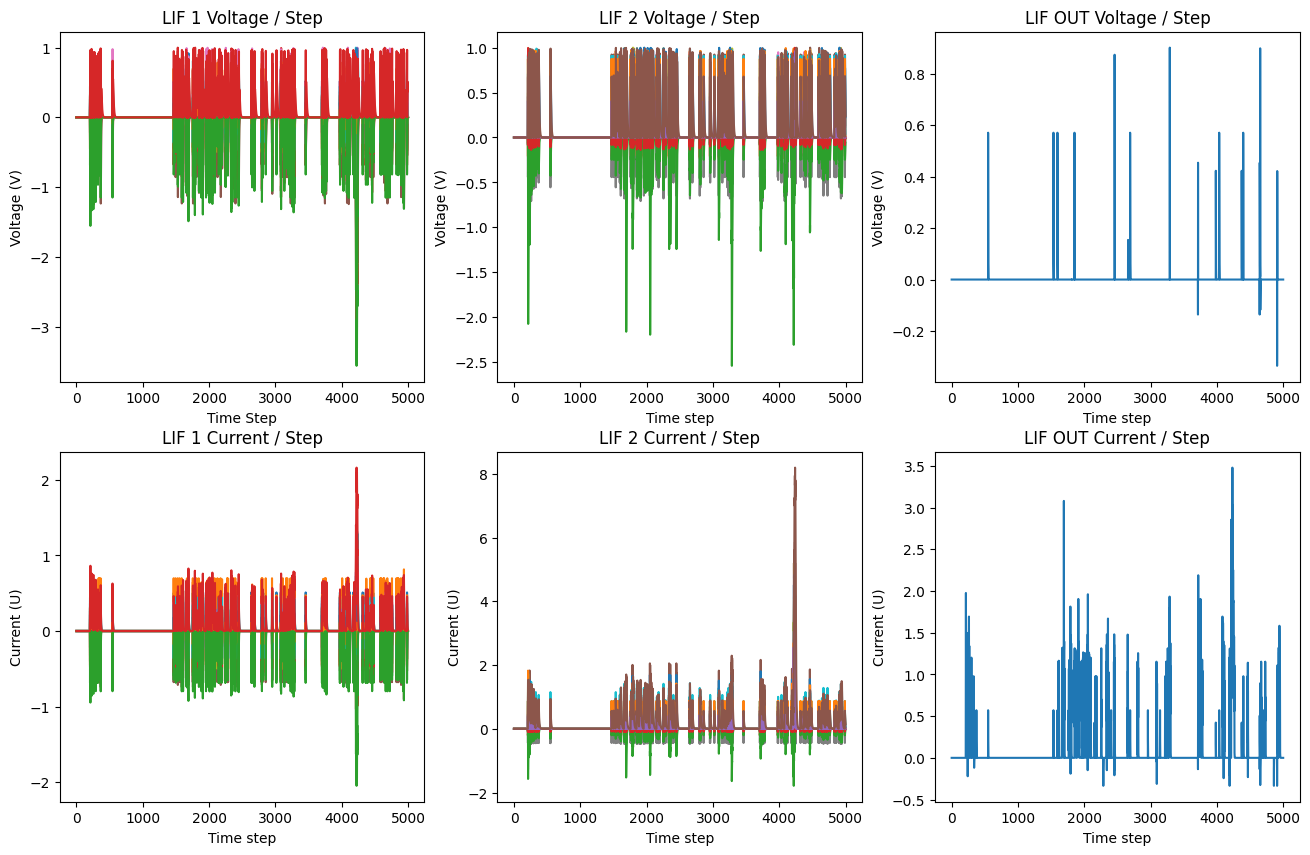

In [199]:
import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt

# Create a subplot for each monitored variable
fig = plt.figure(figsize=(16, 10))
ax0 = fig.add_subplot(2, 3, 1)
ax1 = fig.add_subplot(2, 3, 2)
ax2 = fig.add_subplot(2, 3, 3)
ax3 = fig.add_subplot(2, 3, 4)
ax4 = fig.add_subplot(2, 3, 5)
ax5 = fig.add_subplot(2, 3, 6)

# Plot the data
if MONITOR_ALL:
    monitor_lif1_v.plot(ax0, lif1.v)
    monitor_lif2_v.plot(ax1, lif2.v)
monitor_lif_out_v.plot(ax2, lif_out.v)

if MONITOR_ALL:
    monitor_lif1_u.plot(ax3, lif1.u)
    monitor_lif2_u.plot(ax4, lif2.u)
monitor_lif_out_u.plot(ax5, lif_out.u)

# Set the Title of each Subplot
ax0.set_xlabel('Time Step')
ax0.set_ylabel('Voltage (V)')
ax0.set_title('LIF 1 Voltage / Step')
ax1.set_ylabel('Voltage (V)')
ax1.set_title('LIF 2 Voltage / Step')
ax2.set_ylabel('Voltage (V)')
ax2.set_title('LIF OUT Voltage / Step')


ax3.set_ylabel('Current (U)')
ax3.set_title('LIF 1 Current / Step')
ax4.set_ylabel('Current (U)')
ax4.set_title('LIF 2 Current / Step')
ax5.set_ylabel('Current (U)')
ax5.set_title('LIF OUT Current / Step')

## Find the timesteps where the network spiked

In [200]:
from utils.data_analysis import find_spike_times

lif_out_voltage = np.array(data_lif_out['cuba lif']['v'])
lif_out_current_vals = np.array(data_lif_out['cuba lif']['u'])
# preview_np_array(voltage_arr_1, "Voltage Array")

# Call the find_spike_times util function that detects the spikes in a voltage array
# TODO: Improve the find_spike_times method to view the current of the preview timestep to make sure it is a spike, instead of an inhibition
spike_times_lif_out = find_spike_times(lif_out_voltage, lif_out_current_vals)

print(f"Found {len(spike_times_lif_out)} spikes in the Output LIF Process")
for (spike_time, neuron_idx) in spike_times_lif_out:
    print(f"Spike time: {init_offset + spike_time * virtual_time_step_interval} (iter. {spike_time}) at neuron: {neuron_idx}")

Found 10 spikes in the Output LIF Process
Spike time: 1611 (iter. 1611) at neuron: 0
Spike time: 1854 (iter. 1854) at neuron: 0
Spike time: 2459 (iter. 2459) at neuron: 0
Spike time: 2801 (iter. 2801) at neuron: 0
Spike time: 3088 (iter. 3088) at neuron: 0
Spike time: 3290 (iter. 3290) at neuron: 0
Spike time: 3716 (iter. 3716) at neuron: 0
Spike time: 4080 (iter. 4080) at neuron: 0
Spike time: 4398 (iter. 4398) at neuron: 0
Spike time: 4911 (iter. 4911) at neuron: 0


## Compare the Network Predictions with the Ground Truth

In [201]:
# Define np.array containing the timestep of GT events
gt_times = np.array([int(round(gt_elem[1])) for gt_elem in gt_data])

# Preview the data
preview_np_array(gt_times, "gt_times", edge_items=2)

gt_times Shape: (720,).
Preview: [   4219    6967 ... 3595019 3599000]


In [202]:
real_spike_times = []

prev_spike_anchor = -1
for spike_time, _neuron_idx in spike_times_lif_out:
    if prev_spike_anchor < 0:
        real_spike_times.append(spike_time)
        prev_spike_anchor = spike_time
    else:
        # Check if the current spike time is within the range of the previous spike time
        if (spike_time - prev_spike_anchor) < REFRAC_PERIOD:
            # Skip this spike time
            continue
        else:
            real_spike_times.append(spike_time)
            prev_spike_anchor = spike_time

print(f"Found {len(real_spike_times)} real spikes in the Output LIF Process")
real_spike_times = np.array(real_spike_times)

# Change the number of values printed by numpy print
np.set_printoptions(threshold=1000)  # Set the threshold to a large value
print(real_spike_times)

Found 10 real spikes in the Output LIF Process
[1611 1854 2459 2801 3088 3290 3716 4080 4398 4911]


In [203]:
from utils.hfo import band_to_gt_max_offset

PRED_CAUSALITY_WINDOW = int(5)     # Giving PRED_CAUSALITY_WINDOW ms for the network to update its inner state and spike   

# in timesteps (ms) - Max time from the Insertion Timing to the GT annotation
MAX_DETECTION_OFFSET = int(band_to_gt_max_offset(chosen_band)) * 1.5 + PRED_CAUSALITY_WINDOW   # in timesteps (ms)

print(f"PRED_CAUSALITY_WINDOW: {PRED_CAUSALITY_WINDOW}")
print(f"MAX_DETECTION_OFFSET: {MAX_DETECTION_OFFSET} ms")

PRED_CAUSALITY_WINDOW: 5
MAX_DETECTION_OFFSET: 32.0 ms


We will consider a prediction correct if the network spikes in the interval `[gt_time, gt_time + MAX_DETECTION_OFFSET]`.

In [204]:
TP, TN, FP, FN = 0, 0, 0, 0

curr_gt_idx = 0

for spike_time in real_spike_times:
    # Check if the spike time is within the range of the GT times
    while curr_gt_idx < len(gt_times):
        gt_time = gt_times[curr_gt_idx]
        print(f"GT Time: {gt_time} | Spike Time: {spike_time}")
        if spike_time < gt_time:
            # This spike is before the insertion of a relevant event
            FP += 1
            break   # Exit the loop
        if (spike_time - gt_time) < MAX_DETECTION_OFFSET:
            # spike time must be >= gt_time
            TP += 1
            curr_gt_idx += 1
            break   # Exit the loop
        else:
            # The current spike is not relative to the next GT event
            # meaning that we did not predict the event
            FN += 1
            curr_gt_idx += 1
            continue   # Continue to the next GT event
    else:
        # No more GT events, so every spike is a false positive
        FP += 1


GT Time: 4219 | Spike Time: 1611
GT Time: 4219 | Spike Time: 1854
GT Time: 4219 | Spike Time: 2459
GT Time: 4219 | Spike Time: 2801
GT Time: 4219 | Spike Time: 3088
GT Time: 4219 | Spike Time: 3290
GT Time: 4219 | Spike Time: 3716
GT Time: 4219 | Spike Time: 4080
GT Time: 4219 | Spike Time: 4398
GT Time: 6967 | Spike Time: 4398
GT Time: 6967 | Spike Time: 4911


In [205]:
# Show the Confusion Matrix
print(f"Confusion Matrix:")

# Print lines with same width
print(f"|TP: {TP} | FP: {FP}|\n|FN: {FN}  | TN: {TN}|")

Confusion Matrix:
|TP: 0 | FP: 10|
|FN: 1  | TN: 0|


In [206]:
# Calculate the performance metrics (Not including metrics that rely on TN)
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [207]:
# Output the performance metrics
print(f"Recall (True Positive Rate): {recall*100:.2f} %")
print(f"Precision (TP / (TP + FP)): {precision*100:.2f} %")
print(f"F1 Score (Combines Precision & Recall): {f1_score*100:.2f} %")

Recall (True Positive Rate): 0.00 %
Precision (TP / (TP + FP)): 0.00 %
F1 Score (Combines Precision & Recall): 0.00 %


## Clean up the Network

In [208]:
# Terminates Process Execution for all Network Nodes
spike_event_gen.stop()